In [3]:
#%pip install numpy
%pip install scikit-learn
#%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.0 MB 8.8 MB/s eta 0:00:01
   ------------------ --------------------- 3.7/8.0 MB 8.9 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.0 MB 9.1 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 9.2 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 8.6 MB/s  0:00:00
   ---------------------------------------- 0.0/36.3 MB ? eta -:--:--
   -- ------------------------------------- 1.8/36.3 MB 9.2 MB/s eta 0:00:04
   --- ------------------------------------ 2.9/36.3 MB 7.0 MB/s eta 0:00:05
   ----- ---------------------------------- 4.7/36.3 MB 7.7 MB/s eta 0:00:05
   ------- -------------------------------- 6.8/36.3 MB 8.1 MB/s eta 0:00:04
   --------- ------------------------------ 8.7/36.3 MB 8.3 MB/s eta 0:00:04
   ----------- ------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\doria\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
#Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import os
import sklearn
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

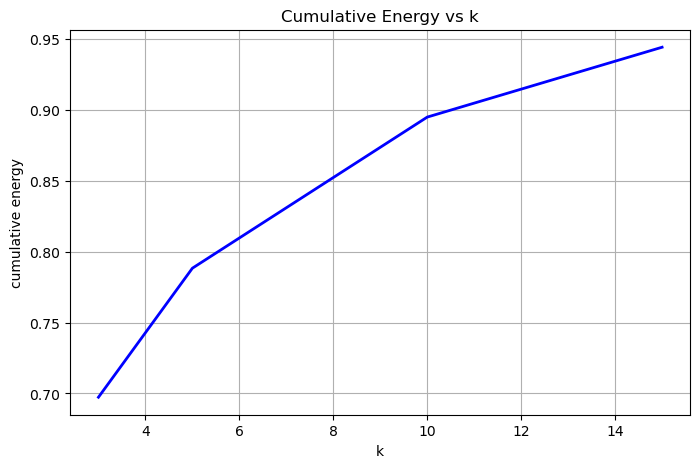

In [81]:
#TASK ONE
#iterate through files and add data to training matrix
los = np.array(["jumping_", "running_", "walking_"])
j = 0
training = np.empty((114, 1500))
for lo in los:
    for i in range(1, 6):
        name = lo + str(i)
        location_name=os.path.join("train", name+".npy")
        vals = np.load(location_name)
        training[:, 100*(j+i-1):100*(j+i)] = vals
    j = j + 5

n = 100
n_vals = np.zeros(4)
energy = np.zeros(4)

#PCA for full data
train_pca_full = PCA(114).fit(training)


full_sv = np.sum(train_pca_full.singular_values_)
pca_sv = full_sv

#while loops to find n for each energy level
while pca_sv/full_sv > 0.95:
    n = n - 1
    train_pca = PCA(n).fit(training)
    pca_sv = np.sum(train_pca.singular_values_)
n_vals[0] = n
energy[0] = pca_sv/full_sv

while pca_sv/full_sv > 0.90:
    n = n - 1
    train_pca = PCA(n).fit(training)
    pca_sv = np.sum(train_pca.singular_values_)
n_vals[1] = n
energy[1] = pca_sv/full_sv

while pca_sv/full_sv > 0.80:
    n = n - 1
    train_pca = PCA(n).fit(training)
    pca_sv = np.sum(train_pca.singular_values_)
n_vals[2] = n
energy[2] = pca_sv/full_sv

while pca_sv/full_sv > 0.70:
    n = n - 1
    train_pca = PCA(n).fit(training)
    pca_sv = np.sum(train_pca.singular_values_)
n_vals[3] = n
energy[3] = pca_sv/full_sv

##MAKE THE PLOT
plt.figure(figsize=(8, 5))
plt.plot(n_vals, energy, label='energy', color='blue', linewidth=2)

# Add labels and title
plt.ylabel('cumulative energy')
plt.xlabel('k')
plt.title('Cumulative Energy vs k')
plt.grid(True)

# Show the plot
plt.show()

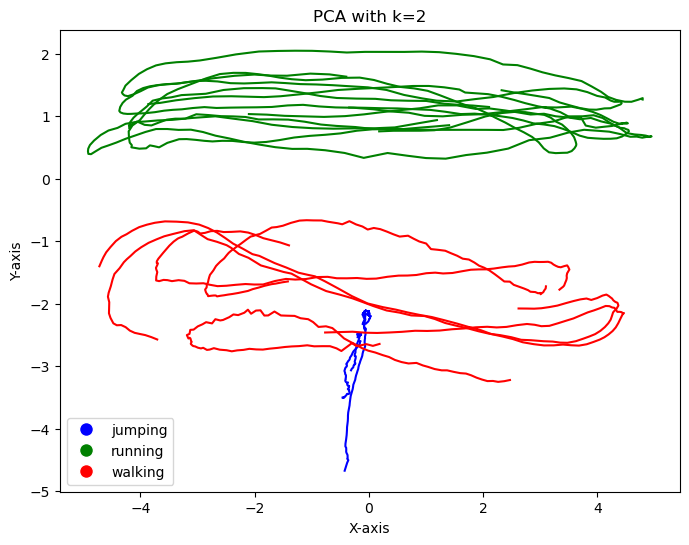

In [75]:
#TASK TWO
#scale data
scaler = StandardScaler()
training_scaled = scaler.fit_transform(training)
samp1_scaled = scaler.fit_transform(training[:, 0:100])

#calculate PCA for k = 2, get U and Uk matrices
pca2 = PCA(114)
pca2.fit(training_scaled.T)
U = pca2.components_.T
Uk = U[:, 0:2]

Z = Uk.T @ samp1_scaled

#create matrix of ground truth labels
labels = np.array([
    0, 0, 0, 0, 0, 
    1, 1, 1, 1, 1,
    2, 2, 2, 2, 2
])

#create plot
fig, ax = plt.subplots(figsize=(8, 6))

z2 = np.zeros((2, 1500))
color = {0: 'blue', 1: 'green', 2: 'red'}
label = {0: 'jumping', 1: 'running', 2: 'walking'}
for i in range(15):
    z= Uk.T @ scaler.fit_transform(training[:, 100*i:100*(i+1)])
    z2[:, 100*i:100*(i+1)] = z
    ax.plot(z[0], z[1], c=color[labels[i]]) 

legend_labels = [plt.Line2D([0], [0], marker='o', color='w', label=label[i], markerfacecolor=color[i], markersize=10) for i in range(3)]    
ax.set_title('PCA with k=2')
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
plt.legend(handles = legend_labels)
plt.show()

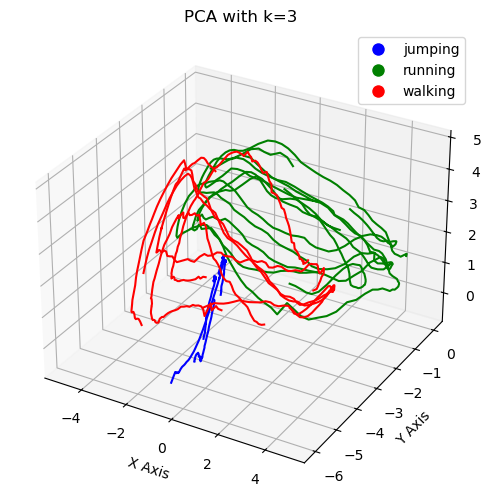

In [76]:
#TASK TWO, continued
#calculate PCA for k = 3, get U and Uk matrices
pca3 = PCA(114).fit(training.T)
U = pca3.components_.T
Uk = U[:, 0:3]

def k_modes(U, k, training, z, n=15):
    #takes U matrix from PCA, k value, training data matrix, empty z matrix, and n value (number of samples) 
    # calculates k modes for each sample and stores in z matrix, returns z
    Uk = U[:, 0:k]
    for i in range(n):
        Xi = scaler.fit_transform(training[:, 100*i:100*(i+1)])
        z_temp= Uk.T @ Xi
        z[:, 100*i:100*(i+1)] = z_temp
    return z

z3 = np.zeros((3, 1500))
z3 = k_modes(U, 3, training, z3)

#create plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
z3 = np.zeros((3, 1500))
for i in range(15):
    Xi = scaler.fit_transform(training[:, 100*i:100*(i+1)])
    z= Uk.T @ Xi
    z3[:, 100*i:100*(i+1)] = z
    plt.plot(z[0], z[1], z[2], c=color[labels[i]]) 

ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.set_title('PCA with k=3')
plt.legend(handles = legend_labels)
plt.show()

In [77]:
#TASK THREE
#create necessary functions
def calc_centroid(z, k):
    #takes transformed data and k value, calculates mean of each movement for each sample, returns matrix of means
    means = np.zeros((k, 15))
    for i in range(15):
        means[:, i] = np.mean(z[:, 100*i:100*(i+1)], axis = 1)
    return means

def calc_mvmt(z, k):
    #takes transformed data and k value, calculates mean of each movement for each sample, then calculates mean of each 
    # movement across all samples, returns matrix of movement means
    mvmt_means = np.zeros((k, 3))
    means = calc_centroid(z, k)
    for i in range(3):
        mvmt_means[:, i] = np.mean(means[:, 5*i:5*(i+1)], axis=1)
    return mvmt_means

#create matrix of ground truth labels
labels = np.array([
    0, 0, 0, 0, 0, 
    1, 1, 1, 1, 1,
    2, 2, 2, 2, 2
])

#calculate movement means for k = 2 and k = 3, print vals
mvmt_means2 = calc_mvmt(z2, 2)
print(mvmt_means2)

mvmt_means3 = calc_mvmt(z3, 3)
print(mvmt_means3)


[[-0.16226923  0.08761198 -0.21574645]
 [-2.62706521  1.07839965 -1.85735366]]
[[-0.1797414   0.0605076  -0.22989063]
 [-4.40293462 -0.81871188 -3.65789583]
 [ 1.63856756  1.74597305  2.43667012]]


In [78]:
#TASK FOUR
##create necessary functions
def calc_distance(z, k, mvmt_means, n = 15):
    #takes transformed samples, number of modes, centroid for each type of movement, and number of samples
    #returns labels for each sample based on closest movement centroid
    labels_trained = np.zeros(n)

    for i in range(n): 
        means = np.mean(z[:, 100*i:100*(i+1)], axis = 1)
        dist = 0
        
        for j in range(k):
            dist = dist + (means[j] - mvmt_means[j, :])**2
            
        dist = np.sqrt(dist)
        min_dist = np.argmin(dist)
        labels_trained[i] = min_dist
    return labels_trained

def calc_accuracy(labels_trained, labels):
    #takes matrix of labels from trained data and matrix of ground truth labels and calculates accuracy of trained labels
    # returns calulated accuracy
    correct = 0
    for i in range(len(labels)):
        if labels_trained[i] == labels[i]:
            correct = correct + 1
    return correct/len(labels)

#testing different k values and calculating accuracy of trained labels
k = 2
labels_trained = calc_distance(z2, k, mvmt_means2)
print(labels_trained)
print(calc_accuracy(labels_trained, labels))

k = 3
labels_trained3 = calc_distance(z3, k, mvmt_means3)
print(labels_trained3)
print(calc_accuracy(labels_trained3, labels))

k = 7
z7 = np.zeros((k, 1500))
z7 = k_modes(U, k, training, z7)
labels_trained7 = calc_distance(z7, k, calc_mvmt(z7, k))
print(labels_trained7)
print(calc_accuracy(labels_trained7, labels))

k = 114
z10 = np.zeros((k, 1500))
z10 = k_modes(U, k, training, z10)
labels_trained10 = calc_distance(z10, k, calc_mvmt(z10, k))
print(labels_trained10)
print(calc_accuracy(labels_trained10, labels))

[2. 0. 2. 0. 0. 1. 1. 1. 1. 1. 2. 0. 2. 2. 2.]
0.8
[2. 0. 2. 0. 0. 1. 1. 1. 1. 1. 2. 0. 2. 2. 2.]
0.8
[2. 0. 0. 0. 0. 1. 1. 1. 1. 1. 2. 2. 2. 2. 2.]
0.9333333333333333
[2. 0. 0. 0. 0. 1. 1. 1. 1. 1. 2. 2. 2. 2. 2.]
0.9333333333333333


In [80]:
##TASK FIVE
#load test data into a testing matrix
los = np.array(["jumping_", "running_", "walking_"])
j = 0
testing = np.empty((114, 300))
#for loop iterates through the movements and adds data 
# from each type of movement into testing matrix
for lo in los:
    name = lo + "1t"
    location_name=os.path.join("test", name+".npy")
    vals = np.load(location_name)
    testing[:, 100*(j):100*(j+1)] = vals
    j = j + 1

#process data by scaling and assigning ground truth labels
testing_scaled = scaler.fit_transform(testing)
labels_gt = np.array([0, 1, 2])

##Classify and compute accuracy for test data
#PCA with 2 modes on test data
k = 2
z2t = np.zeros((k, 300))
z2t = k_modes(U, k, testing_scaled, z2t, 3)
labels_trained2t = calc_distance(z2t, k, calc_mvmt(z2, k), 3)
print("k = 2")
print(labels_trained2t)
print(calc_accuracy(labels_trained2t, labels_gt))

#PCA with 3 modes on test data
k = 3
z3t = np.zeros((k, 300))
z3t = k_modes(U, k, testing_scaled, z3t, 3)
labels_trained2t = calc_distance(z3t, k, calc_mvmt(z3, k), 3)
print("k = 3")
print(labels_trained2t)
print(calc_accuracy(labels_trained2t, labels_gt))

k = 2
[0. 2. 0.]
0.3333333333333333
k = 3
[0. 1. 2.]
1.0
